BAIXANDO BIBLIOTECAS DO DATASUS

In [1]:
!pip install pysus
!pip install dbfread
!pip install pyarrow

In [2]:
from pysus.online_data.SIH import download
import pysus.preprocessing
import pandas as pd
import os

In [3]:
!pip -q install pysus pyarrow fastparquet

CARREGAR LISTA DE ARQUIVOS NO DATASUS

In [4]:
from pysus import SIH

sih = SIH().load()   # carrega a lista de arquivos disponíveis no DATASUS
print("Grupos disponíveis:", sih.groups)

Grupos disponíveis: {'RD': 'AIH Reduzida', 'RJ': 'AIH Rejeitada', 'ER': 'AIH Rejeitada com erro', 'SP': 'Serviços Profissionais', 'CH': 'Cadastro Hospitalar', 'CM': ''}


CARREGAR PERÍODO DE 2022 / 2023 E 2024

In [5]:
anos = [2022, 2023, 2024]
ufs = ["SP", "RJ", "MG", "RS", "PR","SC"]
meses = list(range(1, 13))  # 1..12


In [6]:
files = []
for ano in anos:
    for uf in ufs:
        f = sih.get_files("RD", uf=uf, year=ano, month=meses)
        print(uf, ano, "->", len(f), "arquivos encontrados")
        files.extend(f)

print("TOTAL de arquivos listados:", len(files))

SP 2022 -> 12 arquivos encontrados
RJ 2022 -> 12 arquivos encontrados
MG 2022 -> 12 arquivos encontrados
RS 2022 -> 12 arquivos encontrados
PR 2022 -> 12 arquivos encontrados
SC 2022 -> 12 arquivos encontrados
SP 2023 -> 12 arquivos encontrados
RJ 2023 -> 12 arquivos encontrados
MG 2023 -> 12 arquivos encontrados
RS 2023 -> 12 arquivos encontrados
PR 2023 -> 12 arquivos encontrados
SC 2023 -> 12 arquivos encontrados
SP 2024 -> 12 arquivos encontrados
RJ 2024 -> 12 arquivos encontrados
MG 2024 -> 12 arquivos encontrados
RS 2024 -> 12 arquivos encontrados
PR 2024 -> 12 arquivos encontrados
SC 2024 -> 12 arquivos encontrados
TOTAL de arquivos listados: 216


DOWNLOAD DOS ARQUIVOS

In [7]:
parquets = sih.download(files, local_dir="/content/sih_parquet")
print("TOTAL de parquets baixados:", len(parquets))

RDSC2412.parquet: 100%|██████████| 186k/186k [00:07<00:00, 24.1kB/s]

TOTAL de parquets baixados: 216


ABRINDO ARQUIVOS E ANALISANDO AS INFORMAÇÕES

In [8]:
import pandas as pd

dfs = []
for p in parquets[:5]:  # teste com 5 primeiro
    df = p.to_dataframe()     # método do PySUS para ler parquet
    dfs.append(df)

sih_df = pd.concat(dfs, ignore_index=True)
sih_df.head()

,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,...,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9
0,350000,2022,01,01,50101286000170,3522102812437,1,13481040,352690,20210729,...,,0,0,0,0,0,0,0,0,0
1,350000,2022,01,01,50101286000170,3522102812448,1,37730000,311100,20201215,...,,0,0,0,0,0,0,0,0,0
2,350000,2022,01,01,50101286000170,3522102812459,1,07853040,351640,20150913,...,,0,0,0,0,0,0,0,0,0
3,350000,2022,01,01,50101286000170,3522102812460,1,13457093,354580,20040603,...,,0,0,0,0,0,0,0,0,0
4,350000,2022,01,01,50101286000170,3522102812470,1,13272706,355620,19490323,...,,0,0,0,0,0,0,0,0,0


In [9]:
# 1) quais colunas existem relacionadas a procedimento?
[c for c in sih_df.columns if "PROC" in c.upper()]

['PROC_SOLIC', 'PROC_REA', 'NUM_PROC']

In [10]:
# 2) possíveis colunas de hospital / estabelecimento
[c for c in sih_df.columns if any(k in c.upper() for k in ["CNES", "HOSP", "CGC", "CNPJ", "UNID", "ESTAB","LOCAL"])]

['CGC_HOSP', 'CNES', 'CNPJ_MANT', 'INFEHOSP']

In [11]:
# checar tipos
sih_df.dtypes.head(20)

,0
UF_ZI,string[python]
ANO_CMPT,string[python]
MES_CMPT,string[python]
ESPEC,string[python]
CGC_HOSP,string[python]
N_AIH,string[python]
IDENT,string[python]
CEP,string[python]
MUNIC_RES,string[python]
NASC,string[python]


In [12]:
col_proc = "PROC_REA"   # exemplo
col_hosp = "CNES"       # exemplo


In [13]:
[c for c in sih_df.columns if "PROC" in c.upper()]

['PROC_SOLIC', 'PROC_REA', 'NUM_PROC']

AJUSTANDO COLUNAS

In [14]:
col_proc = "PROC_REA"  # ajuste

sih_df[col_proc].astype(str).str.strip().value_counts().head(10)

,count
PROC_REA,
0310010039,63448
0411010034,44539
0303140151,42779
0303010223,26572
0301060088,25872
0415010012,24537
0303010037,24082
0303100044,17682
0303040149,17526


In [15]:
[c for c in sih_df.columns if "PROC" in c.upper()]

['PROC_SOLIC', 'PROC_REA', 'NUM_PROC']

In [16]:
import os
os.listdir("/content")

['.config', 'sih_parquet', 'sample_data']

TABELAS DE PROCEDIMENTOS NEFROLOGICOS & HOSPITAIS QUE TEM CENTRO CIRURGICOS

In [18]:
import pandas as pd

sigtap = pd.read_excel("/content/sample_data/sigtab_raw.xlsx", dtype=str)
cnes_filtrado = pd.read_excel("/content/sample_data/cnes_centrocir_raw.xlsx", dtype=str)

print(sigtap.shape, cnes_filtrado.shape)
sigtap.head()

(37, 8) (8782, 35)


,Cod. Proc,codigo_sigtap,Procedimento,Complexidade,Modalidade de Atendimento,Serviço Hospital,Servico Profissional,Valor total
0,04.09.01.032-4,0409010324,PIELOPLASTIA,Média Complexidade,Hospitalar,468.88,183.28,652.16
1,04.16.01.001-6,0416010016,AMPUTAÇÃO DE PÊNIS EM ONCOLOGIA,Alta Complexidade,Hospitalar,639.36,199.92,839.28
2,04.16.01.002-4,0416010024,CISTECTOMIA COM DERIVACAO EM 1SÓ TEMPO EM ONCO...,Alta Complexidade,Hospitalar,3167.58,894.87,4062.45
3,04.16.01.004-0,0416010040,CISTOENTEROPLASTIA EM ONCOLOGIA,Alta Complexidade,Hospitalar,3184.82,898.91,4083.73
4,04.16.01.007-5,0416010075,NEFRECTOMIA TOTAL EM ONCOLOGIA,Alta Complexidade,Hospitalar,1316.39,436.91,1753.3


PADRONIZANDO CHAVES

In [19]:
def only_digits(x):
    x = "" if x is None else str(x)
    return "".join(c for c in x if c.isdigit())

# SIGTAP
sigtap["codigo_sigtap"] = sigtap["codigo_sigtap"].apply(only_digits)

# SIH
sih_df["PROC_REA"] = sih_df["PROC_REA"].astype(str).str.strip().apply(only_digits)

In [20]:
sigtap["codigo_sigtap"].head(10), sih_df["PROC_REA"].head(10)

(0    0409010324
 1    0416010016
 2    0416010024
 3    0416010040
 4    0416010075
 5    0416010091
 6    0416010113
 7    0416010121
 8    0416010130
 9    0416010164
 Name: codigo_sigtap, dtype: object,
 0    0404030076
 1    0404030106
 2    0404030122
 3    0404030130
 4    0404020275
 5    0408020628
 6    0408060379
 7    0408060379
 8    0407040102
 9    0408050616
 Name: PROC_REA, dtype: object)

In [21]:
sih_df["CGC_HOSP"] = sih_df["CGC_HOSP"].astype(str).str.strip()
cnes_filtrado["CO_CNES"] = cnes_filtrado["CO_CNES"].astype(str).str.strip()

In [23]:
sih_renal = pd.read_parquet("/content/sample_data/sih_renal_clean.parquet")

print(sih_renal)
sih_renal.head()

          CNES    PROC_REA ANO_CMPT MES_CMPT   UF_ZI
0      2537788  0416010172     2023       12  420420
1      2537788  0416010202     2023       12  420420
2      2537788  0416010172     2023       12  420420
3      2537788  0416010172     2023       12  420420
4      2537788  0416010172     2023       12  420420
...        ...         ...      ...      ...     ...
65631  2237571  0416010130     2024       03  431490
65632  2237571  0416010172     2024       03  431490
65633  2237571  0416010130     2024       03  431490
65634  2237571  0416010130     2024       03  431490
65635  2237571  0409010324     2024       03  431490

[65636 rows x 5 columns]


,CNES,PROC_REA,ANO_CMPT,MES_CMPT,UF_ZI
0,2537788,0416010172,2023,12,420420
1,2537788,0416010202,2023,12,420420
2,2537788,0416010172,2023,12,420420
3,2537788,0416010172,2023,12,420420
4,2537788,0416010172,2023,12,420420


In [24]:
cirurgia_renal = pd.read_parquet("/content/sample_data/fato_cirurgia_renal.parquet")

print(cirurgia_renal)
cirurgia_renal.head()

          CNES    PROC_REA ANO_CMPT MES_CMPT   UF_ZI codigo_sigtap  \
0      2537788  0416010172     2023       12  420420    0416010172   
1      2537788  0416010202     2023       12  420420    0416010202   
2      2537788  0416010202     2023       12  420420    0416010202   
3      2537788  0416010172     2023       12  420420    0416010172   
4      2537788  0416010172     2023       12  420420    0416010172   
...        ...         ...      ...      ...     ...           ...   
66394  2237571  0416010130     2024       03  431490    0416010130   
66395  2237571  0416010172     2024       03  431490    0416010172   
66396  2237571  0416010130     2024       03  431490    0416010130   
66397  2237571  0416010130     2024       03  431490    0416010130   
66398  2237571  0409010324     2024       03  431490    0409010324   

                                            Procedimento        Complexidade  \
0       RESSECÇÃO ENDOSCÓPICA DE TUMOR VESICAL EM ONC...   Alta Complexidade   

,CNES,PROC_REA,ANO_CMPT,MES_CMPT,UF_ZI,codigo_sigtap,Procedimento,Complexidade,Valor_total_num,is_SAM,Gasto_Estimado
0,2537788,0416010172,2023,12,420420,0416010172,RESSECÇÃO ENDOSCÓPICA DE TUMOR VESICAL EM ONC...,Alta Complexidade,1040.42,True,1040.42
1,2537788,0416010202,2023,12,420420,0416010202,SUPRARRENALECTOMIA EM ONCOLOGIA,Alta Complexidade,2711.10,True,2711.10
2,2537788,0416010202,2023,12,420420,0416010202,SUPRARRENALECTOMIA EM ONCOLOGIA,Alta Complexidade,2711.10,True,2711.10
3,2537788,0416010172,2023,12,420420,0416010172,RESSECÇÃO ENDOSCÓPICA DE TUMOR VESICAL EM ONC...,Alta Complexidade,1040.42,True,1040.42
4,2537788,0416010172,2023,12,420420,0416010172,RESSECÇÃO ENDOSCÓPICA DE TUMOR VESICAL EM ONC...,Alta Complexidade,1040.42,True,1040.42


Padronizando Chaves

In [25]:
def only_digits(x):
    x = "" if x is None else str(x)
    return "".join(c for c in x if c.isdigit())

# SIGTAP
sigtap["codigo_sigtap"] = sigtap["codigo_sigtap"].apply(only_digits)

# SIH
sih_renal["PROC_REA"] = sih_renal["PROC_REA"].astype(str).str.strip().apply(only_digits)

In [26]:
sigtap["codigo_sigtap"].head(10), sih_renal["PROC_REA"].head(10)

(0    0409010324
 1    0416010016
 2    0416010024
 3    0416010040
 4    0416010075
 5    0416010091
 6    0416010113
 7    0416010121
 8    0416010130
 9    0416010164
 Name: codigo_sigtap, dtype: object,
 0    0416010172
 1    0416010202
 2    0416010172
 3    0416010172
 4    0416010172
 5    0416010113
 6    0416010172
 7    0416010130
 8    0416010172
 9    0416010016
 Name: PROC_REA, dtype: object)

In [27]:
sih_renal["CNES"] = sih_renal["CNES"].astype(str).str.strip()
cnes_filtrado["CO_CNES"] = cnes_filtrado["CO_CNES"].astype(str).str.strip()

ANÁLISE DE HOSPITAIS QUE POSSUEM CENTRO CIRURGICOS NOS ESTADOS DE SP, RJ, MG, RS, PR E SC E QUANTOS REALIZAM ESPECIFICAMENTE CIRURGIAS RENAIS TAM

In [28]:
codigos_renais = sigtap["codigo_sigtap"].dropna().unique().tolist()
sih_renal = sih_renal[sih_renal["PROC_REA"].isin(codigos_renais)].copy()

# Hospitais que realizaram cirurgia renal
hospitais_ativos = set(sih_renal["CNES"].unique())

# Total hospitais com centro cirúrgico
hospitais_centrocir = set(cnes_filtrado["CO_CNES"].unique())

print("Hospitais com centro cirúrgico:", len(hospitais_centrocir))
print("Hospitais que fizeram cirurgia renal:", len(hospitais_ativos))

Hospitais com centro cirúrgico: 8782
Hospitais que fizeram cirurgia renal: 333


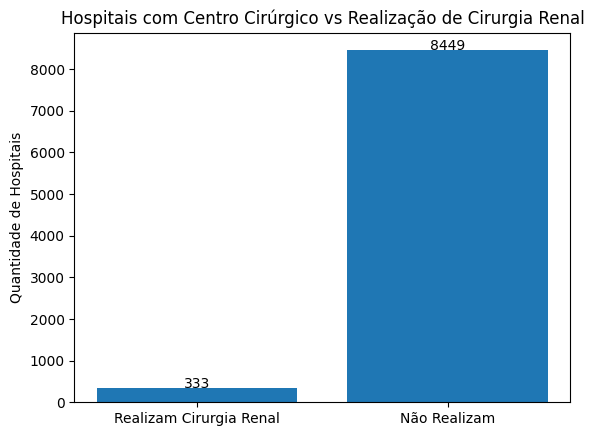

In [29]:
import matplotlib.pyplot as plt

total = len(hospitais_centrocir)
ativos = len(hospitais_ativos)
inativos = total - ativos

labels = ["Realizam Cirurgia Renal", "Não Realizam"]
valores = [ativos, inativos]

plt.figure()
plt.bar(labels, valores)

plt.title("Hospitais com Centro Cirúrgico vs Realização de Cirurgia Renal")
plt.ylabel("Quantidade de Hospitais")

for i, v in enumerate(valores):
    plt.text(i, v + 2, str(v), ha='center')

plt.show()

TOTAL DE INTERNAÇÕES RENAIS

In [30]:
codigos_renais = sigtap["codigo_sigtap"].dropna().unique().tolist()

sih_renal = sih_renal[sih_renal["PROC_REA"].isin(codigos_renais)].copy()
print("Total de internações renais (TAM):", len(sih_renal))

Total de internações renais (TAM): 65636


In [31]:
def padroniza_cnes(x):
    x = str(x)
    x = ''.join(c for c in x if c.isdigit())
    return x.zfill(7)

def limpa_proc(x):
    x = str(x)
    return ''.join(c for c in x if c.isdigit())

# codigos_renais: lista de códigos SIGTAP (já deve existir)
codigos_renais = [limpa_proc(x) for x in codigos_renais]

# CNES filtrado: garanta que está carregado como dataframe "cnes"
cnes_filtrado["CO_CNES"] = cnes_filtrado["CO_CNES"].apply(padroniza_cnes)
set_cnes_ok = set(cnes_filtrado["CO_CNES"].dropna().unique())

VALORES POR PROCEDIMENTO

In [33]:
# Re-initialize sih_renal to a clean state before merging
sih_renal = sih_renal[sih_renal["PROC_REA"].isin(codigos_renais)].copy()

# Clean up sigtap column names to remove any whitespace issues
sigtap.columns = sigtap.columns.str.strip()

# Perform the merge. Since sih_renal is fresh, the new columns will be added without suffixes.
# Assuming columns 'Procedimento', 'Complexidade', 'Valor total' already exist in sih_renal
# from a previous load or merge, the new ones from sigtap will have '_y' suffix.
sih_renal = sih_renal.merge(
    sigtap[["codigo_sigtap", "Procedimento", "Complexidade", "Valor total"]],
    left_on="PROC_REA",
    right_on="codigo_sigtap",
    how="left",
    suffixes=('_x', '_y') # Explicitly add suffixes to make it clear
)

# Display head using the correct (suffixed) column names after the merge
sih_renal[["PROC_REA","Procedimento_y","Complexidade_y","Valor total_y"]].head()

,PROC_REA,Procedimento_y,Complexidade_y,Valor total_y
0,0416010172,RESSECÇÃO ENDOSCÓPICA DE TUMOR VESICAL EM ONC...,Alta Complexidade,1040.42
1,0416010202,SUPRARRENALECTOMIA EM ONCOLOGIA,Alta Complexidade,2711.1
2,0416010202,SUPRARRENALECTOMIA EM ONCOLOGIA,Alta Complexidade,2711.1
3,0416010202,SUPRARRENALECTOMIA EM ONCOLOGIA,Alta Complexidade,2711.1
4,0416010202,SUPRARRENALECTOMIA EM ONCOLOGIA,Alta Complexidade,2711.1


In [36]:
sih_renal["Valor total"] = (
    sih_renal["Valor total_y"]
    .str.replace(",", ".")
    .astype(float)
)

HOSPITAIS QUE MAIS FAZEM CIRURGIAS RENAIS NOME & CUSTO

In [37]:
import pandas as pd

uf_map = {
    11:"RO",12:"AC",13:"AM",14:"RR",15:"PA",16:"AP",17:"TO",
    21:"MA",22:"PI",23:"CE",24:"RN",25:"PB",26:"PE",27:"AL",28:"SE",29:"BA",
    31:"MG",32:"ES",33:"RJ",35:"SP",
    41:"PR",42:"SC",43:"RS",
    50:"MS",51:"MT",52:"GO",53:"DF"
}

sih_renal["UF_cod"] = pd.to_numeric(sih_renal["UF_ZI"].astype(str).str[:2], errors="coerce")
sih_renal = sih_renal[sih_renal["UF_cod"].notna()].copy()
sih_renal["UF"] = sih_renal["UF_cod"].astype(int).map(uf_map)
sih_renal = sih_renal[sih_renal["UF"].notna()].copy()

In [38]:
hospitais_por_uf = (
    sih_renal
    .groupby("UF")
    .agg(
        Hospitais=("CNES", "nunique"),
        Cirurgias=("PROC_REA", "count"),
        Gasto=("Valor total", "sum") # Changed to 'Valor total' as 'Gasto_Estimado' was not present
    )
    .reset_index()
)

hospitais_por_uf["Gasto_Milhoes"] = (hospitais_por_uf["Gasto"] / 1_000_000).round(2)
hospitais_por_uf = hospitais_por_uf.sort_values("Hospitais", ascending=False)

display(hospitais_por_uf)

,UF,Hospitais,Cirurgias,Gasto,Gasto_Milhoes
5,SP,113,28977,62964237.23,62.96
0,MG,60,13135,34420873.13,34.42
3,RS,48,8216,18494316.83,18.49
2,RJ,44,6813,17992718.38,17.99
1,PR,37,6387,13577139.59,13.58
4,SC,31,4397,9357680.88,9.36


In [39]:
top_hosp = (
    sih_renal
    .groupby(["CNES", "UF"])
    .agg(
        Cirurgias=("PROC_REA", "count"),
        Gasto=("Valor total", "sum")
    )
    .reset_index()
)

top_hosp["Gasto_Milhoes"] = (top_hosp["Gasto"] / 1_000_000).round(2)
top_hosp = top_hosp.sort_values("Cirurgias", ascending=False)

In [40]:
col_nome = "NO_FANTASIA" if "NO_FANTASIA" in cnes_filtrado.columns else ("NO_RAZAO_SOCIAL" if "NO_RAZAO_SOCIAL" in cnes_filtrado.columns else None)

if col_nome is None:
    print("Não achei NO_FANTASIA nem NO_RAZAO_SOCIAL no CNES. Vou manter só CNES.")
    top_hosp_named = top_hosp.copy()
else:
    top_hosp_named = top_hosp.merge(
        cnes_filtrado[["CO_CNES", col_nome]],
        left_on="CNES",
        right_on="CO_CNES",
        how="left"
    ).drop(columns=["CO_CNES"])

In [41]:
top5 = top_hosp_named.head(5)
display(top5[["CNES", "UF", col_nome] + ["Cirurgias", "Gasto_Milhoes"]] if col_nome else top5[["CNES","UF","Cirurgias","Gasto_Milhoes"]])

,CNES,UF,NO_FANTASIA,Cirurgias,Gasto_Milhoes
0,2088576,SP,HOSPITALDETRANSPDOESTDESPEURYCLIDESDEJESUSZERBINI,3857,6.67
1,6123740,SP,INSTITUTODOCANCERDOESTADODESAOPAULO,2066,4.61
2,2200457,MG,ASSOCIACAOMARIOPENNA,1987,5.35
3,2083086,SP,HOSPITALAMARALCARVALHOJAU,1838,3.84
4,2090236,SP,FUNDACAOPIOXIIBARRETOS,1762,4.23


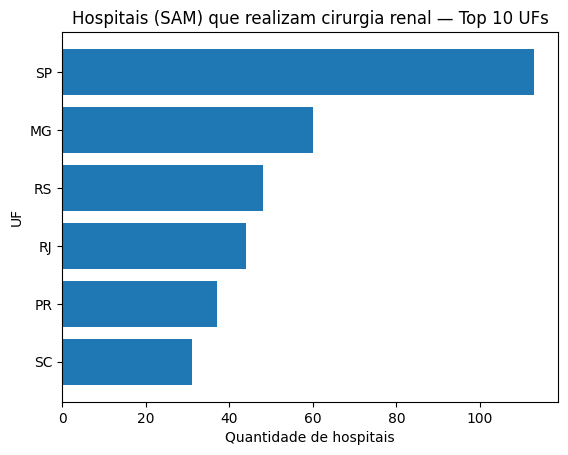

In [42]:
import matplotlib.pyplot as plt

plot = hospitais_por_uf.head(10).sort_values("Hospitais", ascending=True)

plt.figure()
plt.barh(plot["UF"], plot["Hospitais"])
plt.title("Hospitais (SAM) que realizam cirurgia renal — Top 10 UFs")
plt.xlabel("Quantidade de hospitais")
plt.ylabel("UF")
plt.show()

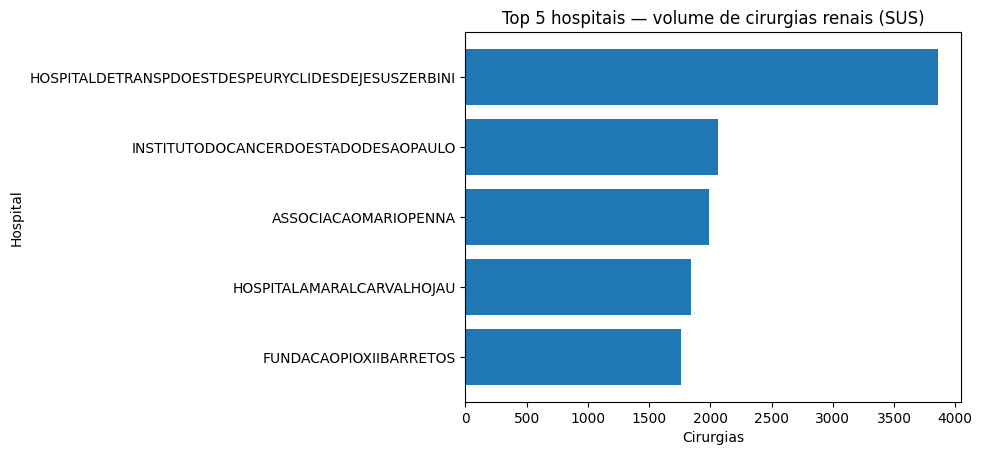

In [43]:
plot = top5.copy()

labels = plot[col_nome].fillna(plot["CNES"]) if col_nome else plot["CNES"]

plt.figure()
plt.barh(labels.iloc[::-1], plot["Cirurgias"].iloc[::-1])
plt.title("Top 5 hospitais — volume de cirurgias renais (SUS)")
plt.xlabel("Cirurgias")
plt.ylabel("Hospital")
plt.show()

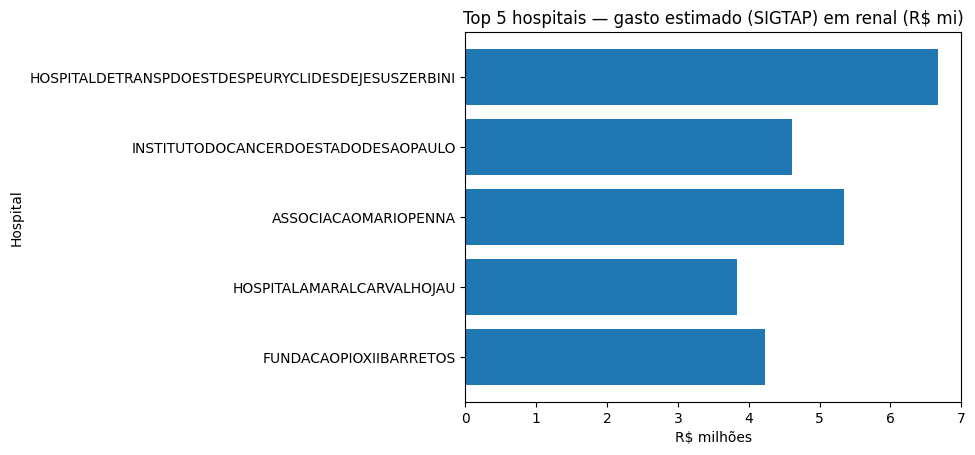

In [44]:
plt.figure()
plt.barh(labels.iloc[::-1], plot["Gasto_Milhoes"].iloc[::-1])
plt.title("Top 5 hospitais — gasto estimado (SIGTAP) em renal (R$ mi)")
plt.xlabel("R$ milhões")
plt.ylabel("Hospital")
plt.show()

In [45]:
top_hosp_named["Custo_medio_por_cirurgia"] = (top_hosp_named["Gasto"] / top_hosp_named["Cirurgias"]).round(2)
display(top_hosp_named.sort_values("Cirurgias", ascending=False).head(10))

,CNES,UF,Cirurgias,Gasto,Gasto_Milhoes,NO_FANTASIA,Custo_medio_por_cirurgia
0,2088576,SP,3857,6667641.39,6.67,HOSPITALDETRANSPDOESTDESPEURYCLIDESDEJESUSZERBINI,1728.71
1,6123740,SP,2066,4609955.80,4.61,INSTITUTODOCANCERDOESTADODESAOPAULO,2231.34
2,2200457,MG,1987,5352978.48,5.35,ASSOCIACAOMARIOPENNA,2694.00
3,2083086,SP,1838,3835543.48,3.84,HOSPITALAMARALCARVALHOJAU,2086.80
4,2090236,SP,1762,4230347.35,4.23,FUNDACAOPIOXIIBARRETOS,2400.88
5,2269783,RJ,1263,3414836.14,3.41,UERJHOSPITALUNIVPEDROERNESTO,2703.75
6,2237571,RS,1212,2605469.85,2.61,HOSPITALNOSSASENHORADACONCEICAO,2149.73
7,0027014,MG,1090,2799899.63,2.80,SANTACASADEBELOHORIZONTE,2568.72
8,2273454,RJ,1065,2935962.88,2.94,MSINCAHOSPITALDOCANCERI,2756.77
9,2159252,MG,1034,2918602.68,2.92,HOSPITALSAOJOAODEDEUS,2822.63


In [46]:
hospitais_por_uf["Custo_Medio"] = (
    hospitais_por_uf["Gasto"] / hospitais_por_uf["Cirurgias"]
).round(2)

hospitais_por_uf[["UF", "Cirurgias", "Gasto_Milhoes", "Custo_Medio"]]

,UF,Cirurgias,Gasto_Milhoes,Custo_Medio
5,SP,28977,62.96,2172.90
0,MG,13135,34.42,2620.55
3,RS,8216,18.49,2251.01
2,RJ,6813,17.99,2640.94
1,PR,6387,13.58,2125.75
4,SC,4397,9.36,2128.20


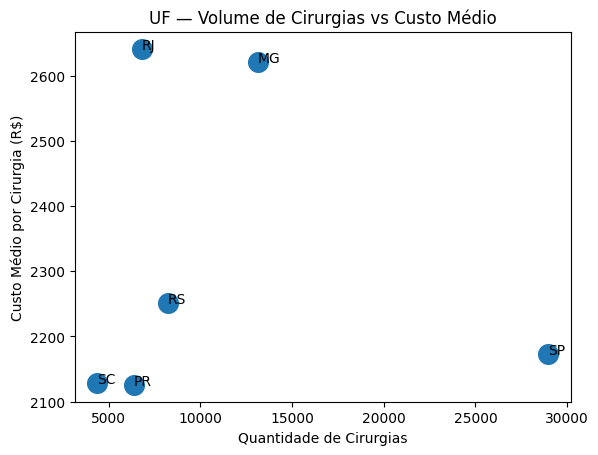

In [47]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    hospitais_por_uf["Cirurgias"],
    hospitais_por_uf["Custo_Medio"],
    s=200
)

for i, row in hospitais_por_uf.iterrows():
    plt.text(row["Cirurgias"], row["Custo_Medio"], row["UF"])

plt.title("UF — Volume de Cirurgias vs Custo Médio")
plt.xlabel("Quantidade de Cirurgias")
plt.ylabel("Custo Médio por Cirurgia (R$)")
plt.show()

In [48]:
top_hosp_named["Custo_Medio"] = (
    top_hosp_named["Gasto"] / top_hosp_named["Cirurgias"]
).round(2)

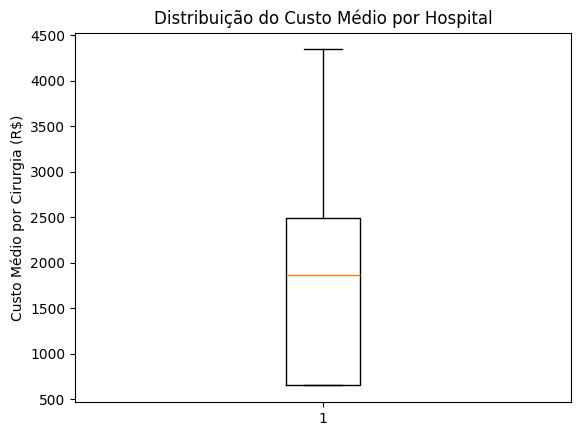

In [49]:
plt.figure()

plt.boxplot(top_hosp_named["Custo_Medio"])

plt.title("Distribuição do Custo Médio por Hospital")
plt.ylabel("Custo Médio por Cirurgia (R$)")
plt.show()

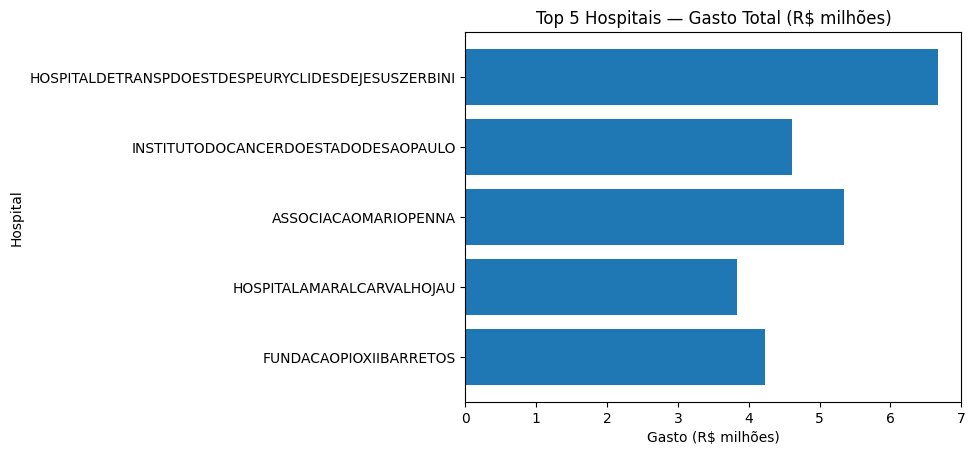

In [50]:
plot = top5.copy()

plt.figure()

plt.barh(
    plot["NO_FANTASIA"][::-1],
    plot["Gasto_Milhoes"][::-1]
)

plt.title("Top 5 Hospitais — Gasto Total (R$ milhões)")
plt.xlabel("Gasto (R$ milhões)")
plt.ylabel("Hospital")

plt.show()

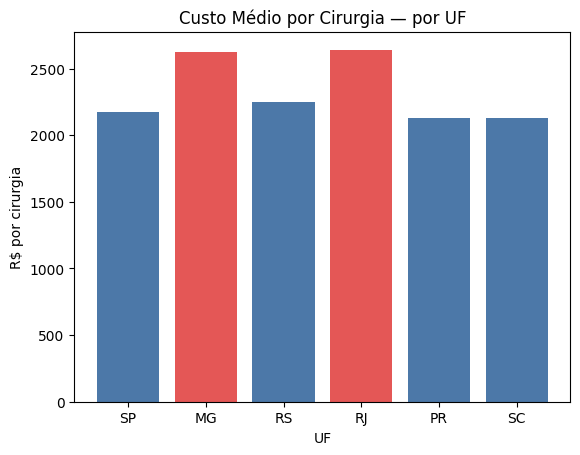

In [51]:
plt.figure()

colors = ["#4C78A8" if x < hospitais_por_uf["Custo_Medio"].mean()
          else "#E45756"
          for x in hospitais_por_uf["Custo_Medio"]]

plt.bar(
    hospitais_por_uf["UF"],
    hospitais_por_uf["Custo_Medio"],
    color=colors
)

plt.title("Custo Médio por Cirurgia — por UF")
plt.ylabel("R$ por cirurgia")
plt.xlabel("UF")
plt.show()

🔵 Azul = abaixo da média
🔴 Vermelho = acima da média

In [52]:
import os

BASE = "/content/drive/MyDrive/justina-bi-robotica2"

# Create the directory if it doesn't exist
os.makedirs(f"{BASE}/data/mart", exist_ok=True)
os.makedirs(f"{BASE}/dashboard", exist_ok=True)

hospitais_por_uf.to_parquet(f"{BASE}/data/mart/hospitais_por_uf.parquet", index=False)
top5.to_parquet(f"{BASE}/data/mart/top5_hospitais.parquet", index=False)

In [53]:
import os

# Verifica se o Drive está montado e se MyDrive existe
print("Existe /content/drive?", os.path.exists("/content/drive"))
print("Existe MyDrive?", os.path.exists("/content/drive/MyDrive"))

# Lista as pastas do MyDrive
print(os.listdir("/content/drive/MyDrive")[:30])

Existe /content/drive? True
Existe MyDrive? True
['justina-bi-robotica2']


In [54]:
BASE = "/content/drive/MyDrive/justina-bi-robotica2"

paths = {
    "raw":     f"{BASE}/data/raw",
    "staging": f"{BASE}/data/staging",
    "mart":    f"{BASE}/data/mart",
    "figs":    f"{BASE}/dashboard/imagens_graficos",
    "notebooks": f"{BASE}/notebooks",
    "src":       f"{BASE}/src",
}

for p in paths.values():
    os.makedirs(p, exist_ok=True)

print("OK. Estrutura atual:")
print("MART:", os.listdir(paths["mart"]))
print("FIGS:", os.listdir(paths["figs"]))
print("NOTEBOOKS:", os.listdir(paths["notebooks"]))
print("SRC:", os.listdir(paths["src"]))

OK. Estrutura atual:
MART: ['top5_hospitais.parquet', 'hospitais_por_uf.parquet']
FIGS: []
NOTEBOOKS: []
SRC: []


In [55]:
to_save = {
    "hospitais_por_uf.parquet": "hospitais_por_uf",
    "top5_hospitais.parquet": "top5",
    "top10_hospitais.parquet": "top10"  # se você tiver
}

for fname, var in to_save.items():
    if var in globals():
        globals()[var].to_parquet(f"{paths['mart']}/{fname}", index=False)
        print("Salvou:", fname)
    else:
        print("Pulei (não existe no notebook):", var)

print("Arquivos em MART agora:")
print(os.listdir(paths["mart"]))

Salvou: hospitais_por_uf.parquet
Salvou: top5_hospitais.parquet
Pulei (não existe no notebook): top10
Arquivos em MART agora:
['top5_hospitais.parquet', 'hospitais_por_uf.parquet']


In [56]:
import matplotlib.pyplot as plt
import time, os

# EXEMPLO: depois de gerar seu gráfico (não precisa recriar aqui),
# salve com um nome único para você ver aparecer:
out_file = f"{paths['figs']}/novo_grafico_{int(time.time())}.png"

plt.savefig(out_file, dpi=200, bbox_inches="tight")
plt.close()

print("Salvo?", os.path.exists(out_file))
print("FIGS agora:", os.listdir(paths["figs"])[-10:])

Salvo? True
FIGS agora: ['novo_grafico_1772731108.png']


In [57]:
import shutil, glob, os

# tenta achar notebooks no /content
nb = glob.glob("/content/*.ipynb")
print("Notebooks em /content:", nb)

# se aparecer um notebook, copie para a pasta notebooks
if nb:
    shutil.copy(nb[0], f"{paths['notebooks']}/{os.path.basename(nb[0])}")
    print("Copiado para notebooks/")

Notebooks em /content: []


In [58]:
print("MART:", os.listdir(paths["mart"]))
print("FIGS:", os.listdir(paths["figs"])[-10:])
print("NOTEBOOKS:", os.listdir(paths["notebooks"]))

MART: ['top5_hospitais.parquet', 'hospitais_por_uf.parquet']
FIGS: ['novo_grafico_1772731108.png']
NOTEBOOKS: []


In [ ]:
import shutil

shutil.rmtree('/content/drive')

TAM POR ESTADO

In [60]:
tam_uf = (
    sih_renal
    .groupby("UF")
    .agg(
        Cirurgias=("PROC_REA", "count")
    )
    .reset_index()
)

tam_uf

,UF,Cirurgias
0,MG,13135
1,PR,6387
2,RJ,6813
3,RS,8216
4,SC,4397
5,SP,28977


SAM POR ESTADO

In [61]:
sam_uf = (
    sih_renal
    .groupby("UF")
    .agg(
        Hospitais=("CNES", "nunique")
    )
    .reset_index()
)

sam_uf

,UF,Hospitais
0,MG,60
1,PR,37
2,RJ,44
3,RS,48
4,SC,31
5,SP,113


GASTO POR ESTADO

In [62]:
hospitais_por_uf = (
    sih_renal
    .groupby("UF")
    .agg(
        Hospitais=("CNES", "nunique"),
        Cirurgias=("PROC_REA", "count"),
        Gasto=("Valor total", "sum") # Corrected column name to 'Valor total'
    )
    .reset_index()
)

hospitais_por_uf["Gasto_Milhoes"] = hospitais_por_uf["Gasto"] / 1_000_000

hospitais_por_uf

,UF,Hospitais,Cirurgias,Gasto,Gasto_Milhoes
0,MG,60,13135,34420873.13,34.420873
1,PR,37,6387,13577139.59,13.577140
2,RJ,44,6813,17992718.38,17.992718
3,RS,48,8216,18494316.83,18.494317
4,SC,31,4397,9357680.88,9.357681
5,SP,113,28977,62964237.23,62.964237


RANKING HOSPITAIS

In [63]:
# Ensure 'CNES' in sih_renal and 'CO_CNES' in cnes_filtrado are of consistent type for merging
sih_renal['CNES'] = sih_renal['CNES'].astype(str)
cnes_filtrado['CO_CNES'] = cnes_filtrado['CO_CNES'].astype(str)

# Perform the merge to add hospital names to sih_renal
# We use the 'col_nome' variable that was already determined to hold the correct name column (e.g., 'NO_FANTASIA')
sih_renal_with_names = sih_renal.merge(
    cnes_filtrado[['CO_CNES', col_nome]],
    left_on='CNES',
    right_on='CO_CNES',
    how='left'
).drop(columns=['CO_CNES']) # Drop the redundant CO_CNES column after merging

# Rename the merged column to 'NO_FANTASIA' for consistency in groupby, if 'col_nome' is not already 'NO_FANTASIA'
# This step ensures the groupby key explicitly uses 'NO_FANTASIA'.
if col_nome != 'NO_FANTASIA':
    sih_renal_with_names.rename(columns={col_nome: 'NO_FANTASIA'}, inplace=True)

top_hospitais = (
    sih_renal_with_names
    .groupby(["CNES", "NO_FANTASIA", "UF"])
    .agg(
        Cirurgias=("PROC_REA", "count"),
        Gasto=("Valor total", "sum") # Corrected from VAL_TOT to Valor total
    )
    .reset_index()
)

top_hospitais["Gasto_Milhoes"] = top_hospitais["Gasto"] / 1_000_000

top5 = top_hospitais.sort_values("Cirurgias", ascending=False).head(10)

top5

,CNES,NO_FANTASIA,UF,Cirurgias,Gasto,Gasto_Milhoes
90,2088576,HOSPITALDETRANSPDOESTDESPEURYCLIDESDEJESUSZERBINI,SP,3857,6667641.39,6.667641
311,6123740,INSTITUTODOCANCERDOESTADODESAOPAULO,SP,2066,4609955.80,4.609956
127,2200457,ASSOCIACAOMARIOPENNA,MG,1987,5352978.48,5.352978
80,2083086,HOSPITALAMARALCARVALHOJAU,SP,1838,3835543.48,3.835543
93,2090236,FUNDACAOPIOXIIBARRETOS,SP,1762,4230347.35,4.230347
184,2269783,UERJHOSPITALUNIVPEDROERNESTO,RJ,1263,3414836.14,3.414836
150,2237571,HOSPITALNOSSASENHORADACONCEICAO,RS,1212,2605469.85,2.605470
25,0027014,SANTACASADEBELOHORIZONTE,MG,1090,2799899.63,2.799900
189,2273454,MSINCAHOSPITALDOCANCERI,RJ,1065,2935962.88,2.935963
116,2159252,HOSPITALSAOJOAODEDEUS,MG,1034,2918602.68,2.918603


In [64]:
top_hospitais = (
    sih_renal_with_names
    .groupby(["CNES", "NO_FANTASIA", "UF"])
    .agg(
        Cirurgias=("PROC_REA", "count"),
        Gasto=("Valor total", "sum")
    )
    .reset_index()
)

top_hospitais["Gasto_Milhoes"] = top_hospitais["Gasto"] / 1_000_000

top5 = top_hospitais.sort_values("Cirurgias", ascending=False).head(10)

top5

,CNES,NO_FANTASIA,UF,Cirurgias,Gasto,Gasto_Milhoes
90,2088576,HOSPITALDETRANSPDOESTDESPEURYCLIDESDEJESUSZERBINI,SP,3857,6667641.39,6.667641
311,6123740,INSTITUTODOCANCERDOESTADODESAOPAULO,SP,2066,4609955.80,4.609956
127,2200457,ASSOCIACAOMARIOPENNA,MG,1987,5352978.48,5.352978
80,2083086,HOSPITALAMARALCARVALHOJAU,SP,1838,3835543.48,3.835543
93,2090236,FUNDACAOPIOXIIBARRETOS,SP,1762,4230347.35,4.230347
184,2269783,UERJHOSPITALUNIVPEDROERNESTO,RJ,1263,3414836.14,3.414836
150,2237571,HOSPITALNOSSASENHORADACONCEICAO,RS,1212,2605469.85,2.605470
25,0027014,SANTACASADEBELOHORIZONTE,MG,1090,2799899.63,2.799900
189,2273454,MSINCAHOSPITALDOCANCERI,RJ,1065,2935962.88,2.935963
116,2159252,HOSPITALSAOJOAODEDEUS,MG,1034,2918602.68,2.918603


In [65]:
tam_uf.to_csv("tam_uf.csv", index=False)

sam_uf.to_csv("sam_uf.csv", index=False)

hospitais_por_uf.to_csv("hospitais_por_uf.csv", index=False)

top5.to_csv("top_hospitais.csv", index=False)

In [66]:
tam_uf = (
    sih_renal
    .groupby("UF")
    .agg(
        Cirurgias=("PROC_REA", "count")
    )
    .reset_index()
)

tam_uf

,UF,Cirurgias
0,MG,13135
1,PR,6387
2,RJ,6813
3,RS,8216
4,SC,4397
5,SP,28977


In [67]:
sam_uf = (
    sih_renal
    .groupby("UF")
    .agg(
        Hospitais=("CNES", "nunique")
    )
    .reset_index()
)

sam_uf

,UF,Hospitais
0,MG,60
1,PR,37
2,RJ,44
3,RS,48
4,SC,31
5,SP,113


In [68]:
hospitais_por_uf = (
    sih_renal
    .groupby("UF")
    .agg(
        Hospitais=("CNES", "nunique"),
        Cirurgias=("PROC_REA", "count"),
        Gasto=("Valor total", "sum") # Corrected column name
    )
    .reset_index()
)

hospitais_por_uf["Gasto_Milhoes"] = hospitais_por_uf["Gasto"] / 1_000_000

hospitais_por_uf

,UF,Hospitais,Cirurgias,Gasto,Gasto_Milhoes
0,MG,60,13135,34420873.13,34.420873
1,PR,37,6387,13577139.59,13.577140
2,RJ,44,6813,17992718.38,17.992718
3,RS,48,8216,18494316.83,18.494317
4,SC,31,4397,9357680.88,9.357681
5,SP,113,28977,62964237.23,62.964237


In [69]:
!pip install openpyxl

tam_uf.to_excel("tam_uf.xlsx", index=False)

sam_uf.to_excel("sam_uf.xlsx", index=False)

hospitais_por_uf.to_excel("hospitais_por_uf.xlsx", index=False)

top5.to_excel("top_hospitais.xlsx", index=False)

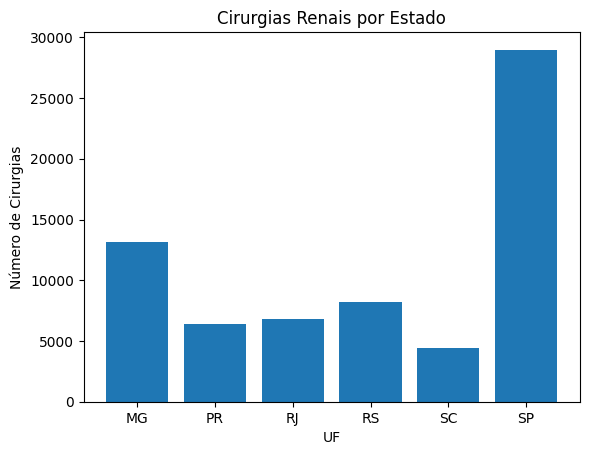

In [70]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(hospitais_por_uf["UF"], hospitais_por_uf["Cirurgias"])
plt.title("Cirurgias Renais por Estado")
plt.xlabel("UF")
plt.ylabel("Número de Cirurgias")
plt.show()

In [ ]:
!du -sh /content/sih_parquet

1.2G	/content/sih_parquet


In [71]:
!git clone https://github.com/No-Country-simulation/S02-26-Equipe-64-BI/blob/main/justina-bi/notebooks

Cloning into 'notebooks'...
fatal: repository 'https://github.com/No-Country-simulation/S02-26-Equipe-64-BI/blob/main/justina-bi/notebooks/' not found


In [72]:
!cp "/content/Business Intelligence para Robótica Cirúrgica.ipynb" "/content/https://github.com/No-Country-simulation/S02-26-Equipe-64-BI/justina-bi/notebooks"

cp: cannot stat '/content/Business Intelligence para Robótica Cirúrgica.ipynb': No such file or directory


In [ ]:
!mkdir -p "/content/https://github.com/No-Country-simulation/S02-26-Equipe-64-BI"

In [ ]:
%cd /content/https://github.com/No-Country-simulation/S02-26-Equipe-64-BI

/content/https:/github.com/No-Country-simulation/S02-26-Equipe-64-BI


In [ ]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!pwd

/content/https:/github.com/No-Country-simulation/S02-26-Equipe-64-BI


In [ ]:
%cd /content

/content


In [ ]:
!ls

 cnes_centrocir_raw.xlsx			       sample_data
 cnes_clean.parquet				       sam_uf.parquet
 fato_cirurgia_renal.parquet			       sigtab_raw.xlsx
 https:						       sigtap_clean.parquet
'justina-bi-robotica-20260302T145651Z-1-001 (1).zip'   sih_renal_clean.parquet
 S02-26-Equipe-64-BI				       tam_uf.parquet


In [ ]:
%cd /content/S02-26-Equipe-64-BI

/content/S02-26-Equipe-64-BI


In [ ]:
!pwd
!ls -la

/content/S02-26-Equipe-64-BI
total 20
drwxr-xr-x 4 root root 4096 Mar  3 02:04 .
drwxr-xr-x 1 root root 4096 Mar  3 02:08 ..
drwxr-xr-x 8 root root 4096 Mar  3 02:04 .git
-rw-r--r-- 1 root root    0 Mar  3 02:04 .gitignore
drwxr-xr-x 4 root root 4096 Mar  3 02:04 justina-bi
-rw-r--r-- 1 root root  487 Mar  3 02:04 README.md


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
%cd /content/S02-26-Equipe-64-BI
!mkdir -p notebooks
!cp "/content/Pipeline.ipynb" "notebooks/"
!git add .
!git commit -m "Adiciona notebook do Colab"
!git push

/content/S02-26-Equipe-64-BI
cp: cannot stat '/content/Pipeline.ipynb': No such file or directory
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@0b82dac2d3dc.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
import matplotlib.pyplot as plt

# Ensure 'Custo_Medio' is available for hospitais_por_uf
hospitais_por_uf["Custo_Medio"] = (
    hospitais_por_uf["Gasto"] / hospitais_por_uf["Cirurgias"]
).round(2)

# Ensure 'Custo_Medio' is available for top_hosp_named
top_hosp_named["Custo_Medio"] = (
    top_hosp_named["Gasto"] / top_hosp_named["Cirurgias"]
).round(2)

# ===============================
# 1 Hospitais com Centro Cirúrgico vs Cirurgia Renal
# ===============================

plt.figure()

labels = ["Centro Cirúrgico", "Cirurgia Renal"]
values = [total, ativos]

plt.bar(labels, values)

plt.title("Hospitais com Centro Cirúrgico vs Realização de Cirurgia Renal")
plt.ylabel("Quantidade de hospitais")

plt.savefig(f"{paths['figs']}/centro_cirurgico_vs_renal.png", dpi=200, bbox_inches="tight")
plt.close()


# ===============================
# 2 Hospitais (SAM) Top 10 UFs
# ===============================

p = hospitais_por_uf.sort_values("Hospitais", ascending=True).tail(10)

plt.figure()

plt.barh(p["UF"], p["Hospitais"])

plt.title("Hospitais (SAM) que realizam cirurgia renal — Top 10 UFs")
plt.xlabel("Quantidade de hospitais")
plt.ylabel("UF")

plt.savefig(f"{paths['figs']}/sam_top10_ufs.png", dpi=200, bbox_inches="tight")
plt.close()


# ===============================
# 3 Top 5 hospitais volume
# ===============================

p = top5.sort_values("Cirurgias", ascending=True)

plt.figure()

plt.barh(p["NO_FANTASIA"], p["Cirurgias"])

plt.title("Top 5 hospitais — volume de cirurgias renais (SUS)")
plt.xlabel("Quantidade de cirurgias")
plt.ylabel("Hospital")

plt.savefig(f"{paths['figs']}/top5_volume_hospitais.png", dpi=200, bbox_inches="tight")
plt.close()


# ===============================
# 4 Top 5 hospitais gasto
# ===============================

p = top5.sort_values("Gasto_Milhoes", ascending=True)

plt.figure()

plt.barh(p["NO_FANTASIA"], p["Gasto_Milhoes"])

plt.title("Top 5 hospitais — gasto estimado (SIGTAP) em renal (R$ mi)")
plt.xlabel("R$ milhões")
plt.ylabel("Hospital")

plt.savefig(f"{paths['figs']}/top5_gasto_hospitais.png", dpi=200, bbox_inches="tight")
plt.close()


# ===============================
# 5 Volume vs custo médio UF
# ===============================

plt.figure()

plt.scatter(
    hospitais_por_uf["Cirurgias"],
    hospitais_por_uf["Custo_Medio"]
)

for i in range(len(hospitais_por_uf)):
    plt.text(
        hospitais_por_uf["Cirurgias"].iloc[i],
        hospitais_por_uf["Custo_Medio"].iloc[i],
        hospitais_por_uf["UF"].iloc[i]
    )

plt.title("UF — Volume de Cirurgias vs Custo Médio")
plt.xlabel("Quantidade de cirurgias")
plt.ylabel("Custo médio por cirurgia (R$)")

plt.savefig(f"{paths['figs']}/volume_vs_custo_uf.png", dpi=200, bbox_inches="tight")
plt.close()


# ===============================
# 6 Distribuição custo médio hospital
# ===============================

plt.figure()

plt.boxplot(top_hosp_named["Custo_Medio"])

plt.title("Distribuição do Custo Médio por Hospital")
plt.ylabel("Custo médio por cirurgia (R$)")

plt.savefig(f"{paths['figs']}/distribuicao_custo_hospital.png", dpi=200, bbox_inches="tight")
plt.close()


# ===============================
# 7 Top 5 gasto total hospitais
# ===============================

p = top5.sort_values("Gasto_Milhoes", ascending=True)

plt.figure()

plt.barh(p["NO_FANTASIA"], p["Gasto_Milhoes"])

plt.title("Top 5 Hospitais — Gasto Total (R$ milhões)")
plt.xlabel("R$ milhões")
plt.ylabel("Hospital")

plt.savefig(f"{paths['figs']}/top5_gasto_total.png", dpi=200, bbox_inches="tight")
plt.close()


# ===============================
# 8 Custo médio por UF
# ===============================

p = hospitais_por_uf.sort_values("Custo_Medio", ascending=True)

plt.figure()

plt.bar(p["UF"], p["Custo_Medio"])

plt.title("Custo Médio por Cirurgia — por UF")
plt.xlabel("UF")
plt.ylabel("Custo médio por cirurgia (R$)")

plt.savefig(f"{paths['figs']}/custo_medio_por_uf.png", dpi=200, bbox_inches="tight")
plt.close()


print("Todos os gráficos foram salvos em:", paths["figs"])

Todos os gráficos foram salvos em: /content/drive/MyDrive/justina-bi-robotica2/dashboard/imagens_graficos
